In [1]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from contextlib import nullcontext
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms

print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")

device = (
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available()          else
    "cpu"
)
print(f"Device      : {device}\n")

DATA_DIR  = Path("data")
TINY_ROOT = DATA_DIR / "tiny-imagenet-200"

PyTorch     : 2.10.0
Torchvision : 0.25.0
Device      : mps



In [2]:
for p in sorted(TINY_ROOT.iterdir()):
    print(p)

sample_class = sorted((TINY_ROOT / "train").iterdir())[0]
print(f"\nSample class dir : {sample_class}")
print(f"Sub-contents     : {list(sample_class.iterdir())}")
sample_imgs = list((sample_class / "images").iterdir())[:3]
print(f"Sample images    : {sample_imgs}")


data/tiny-imagenet-200/.DS_Store
data/tiny-imagenet-200/test
data/tiny-imagenet-200/train
data/tiny-imagenet-200/val
data/tiny-imagenet-200/wnids.txt
data/tiny-imagenet-200/words.txt

Sample class dir : data/tiny-imagenet-200/train/n01443537
Sub-contents     : [PosixPath('data/tiny-imagenet-200/train/n01443537/images'), PosixPath('data/tiny-imagenet-200/train/n01443537/n01443537_boxes.txt')]
Sample images    : [PosixPath('data/tiny-imagenet-200/train/n01443537/images/n01443537_254.JPEG'), PosixPath('data/tiny-imagenet-200/train/n01443537/images/n01443537_311.JPEG'), PosixPath('data/tiny-imagenet-200/train/n01443537/images/n01443537_468.JPEG')]


In [3]:
from dataset import TinyImageNet

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 64
BATCH_SIZE    = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = TinyImageNet(DATA_DIR, split="train", transform=train_transform)
val_dataset   = TinyImageNet(DATA_DIR, split="val",   transform=val_transform)
print(f"\nTrain samples : {len(train_dataset):,}")
print(f"Val   samples : {len(val_dataset):,}")
print(f"Classes       : {len(train_dataset.class_names)}")
print(f"First 10 classes: {train_dataset.class_names[:10]}")

_pin     = device == "cuda"
_workers = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=_workers,
    pin_memory=_pin,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=_workers,
    pin_memory=_pin,
)
print(f"\nTrain batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")


Train samples : 100,000
Val   samples : 10,000
Classes       : 200
First 10 classes: ['goldfish', 'European fire salamander', 'bullfrog', 'tailed frog', 'American alligator', 'boa constrictor', 'trilobite', 'scorpion', 'black widow', 'tarantula']

Train batches : 3125
Val   batches : 313


Number of patches (N) with H=224, W=224, P=16: 196
Input shape  (single 2D image)        : (224, 224, 3)
Output shape (flattened into patches) : (196, 768)


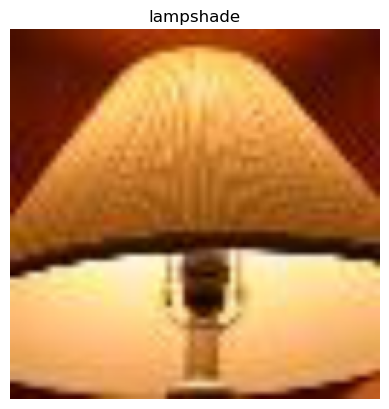

In [5]:
_VIZ_SIZE  = 224
_VIZ_PATCH = 16

_raw_transform = transforms.Compose([
    transforms.Resize((_VIZ_SIZE, _VIZ_SIZE)),
    transforms.ToTensor(),
])
_raw_ds = TinyImageNet(DATA_DIR, split="val", transform=_raw_transform)

image, sample_label = _raw_ds[73]
image_permuted = image.permute(1, 2, 0)
class_name = train_dataset.class_names[sample_label]

height = width = _VIZ_SIZE
color_channels = 3
PATCH_SIZE = _VIZ_PATCH

# Eq. 1: N = HW / P^2
number_of_patches = int((height * width) / PATCH_SIZE**2)
print(f"Number of patches (N) with H={height}, W={width}, P={PATCH_SIZE}: {number_of_patches}")

embedding_layer_input_shape  = (height, width, color_channels)
embedding_layer_output_shape = (number_of_patches, PATCH_SIZE**2 * color_channels)
print(f"Input shape  (single 2D image)        : {embedding_layer_input_shape}")
print(f"Output shape (flattened into patches) : {embedding_layer_output_shape}")

plt.imshow(image_permuted)
plt.title(class_name)
plt.axis(False);

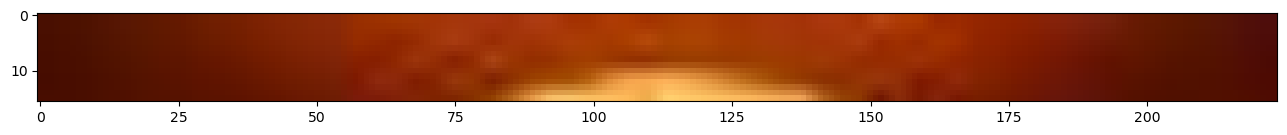

In [6]:
plt.figure(figsize=(PATCH_SIZE, PATCH_SIZE))
plt.imshow(image_permuted[:PATCH_SIZE, :, :]);

Number of patches per row: 14
Patch size: 16 pixels x 16 pixels


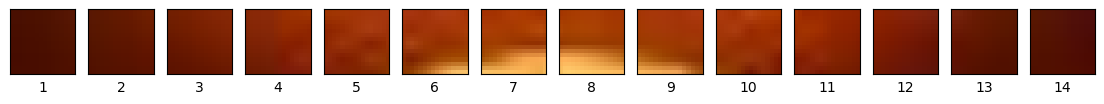

In [7]:
num_patches = _VIZ_SIZE // PATCH_SIZE
print(f"Number of patches per row: {num_patches}")
print(f"Patch size: {PATCH_SIZE} pixels x {PATCH_SIZE} pixels")

fig, axs = plt.subplots(
    nrows=1, ncols=num_patches,
    figsize=(num_patches, num_patches),
    sharex=True, sharey=True
)
for i, patch in enumerate(range(0, _VIZ_SIZE, PATCH_SIZE)):
    axs[i].imshow(image_permuted[:PATCH_SIZE, patch:patch+PATCH_SIZE, :])
    axs[i].set_xlabel(i+1)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

Patches per row: 14  |  Patches per col: 14  |  Total: 196
Patch size: 16x16 pixels


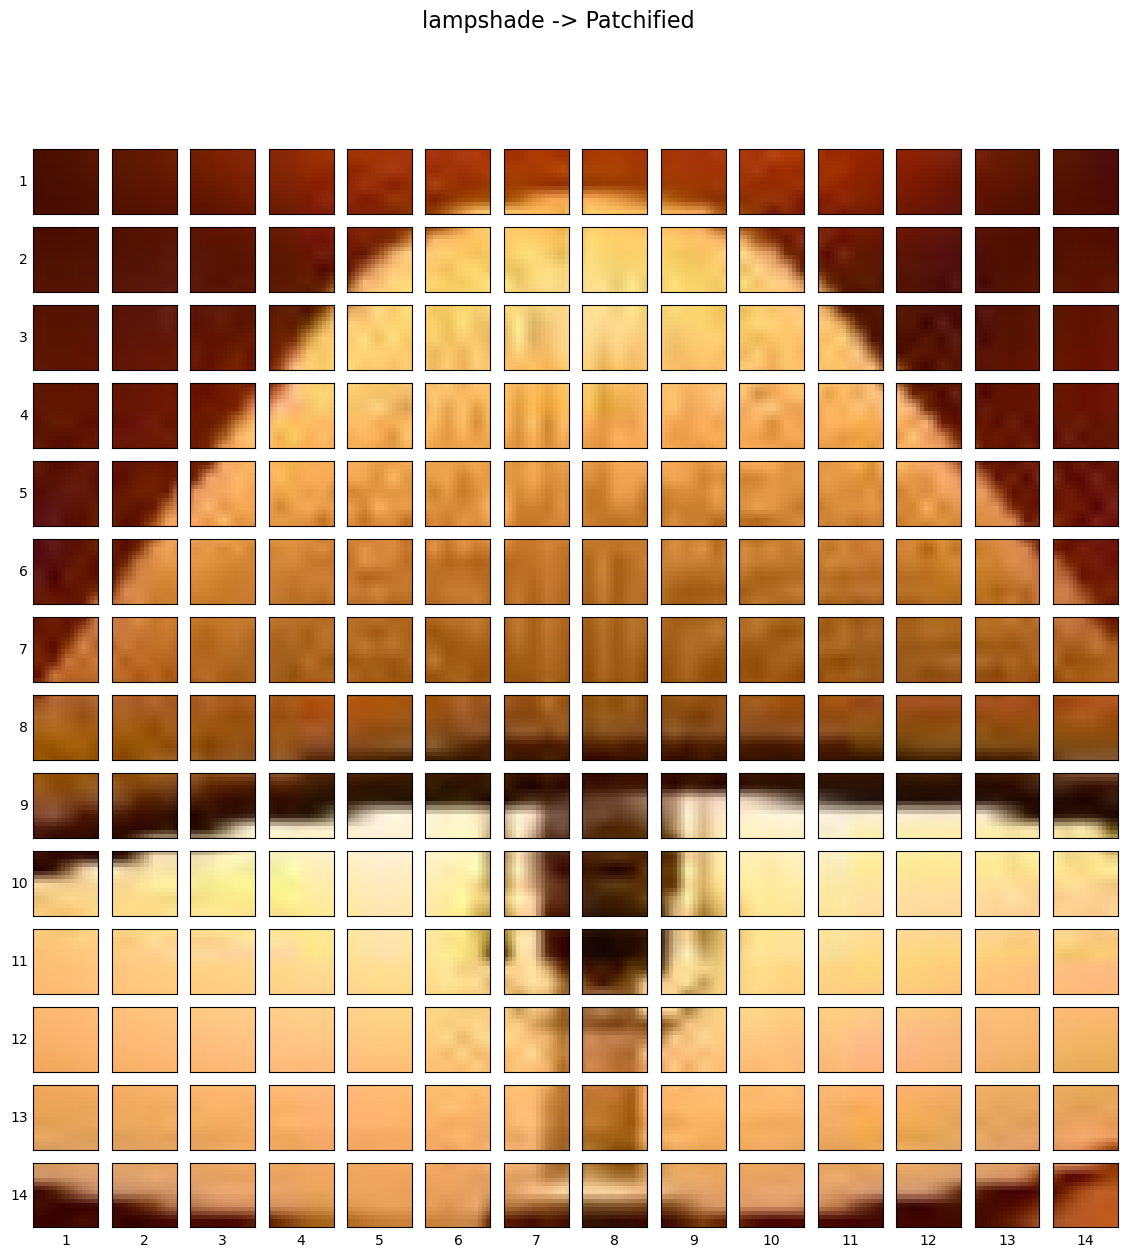

In [8]:
num_patches = _VIZ_SIZE // PATCH_SIZE
print(f"Patches per row: {num_patches}  |  Patches per col: {num_patches}  |  Total: {num_patches*num_patches}")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE} pixels")

fig, axs = plt.subplots(
    nrows=num_patches,
    ncols=num_patches,
    figsize=(num_patches, num_patches),
    sharex=True,
    sharey=True
)
for i, patch_height in enumerate(range(0, _VIZ_SIZE, PATCH_SIZE)):
    for j, patch_width in enumerate(range(0, _VIZ_SIZE, PATCH_SIZE)):
        axs[i, j].imshow(
            image_permuted[patch_height:patch_height+PATCH_SIZE,
                           patch_width:patch_width+PATCH_SIZE, :]
        )
        axs[i, j].set_ylabel(i+1, rotation="horizontal",
                              horizontalalignment="right", verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

fig.suptitle(f"{class_name} -> Patchified", fontsize=16)
plt.show()

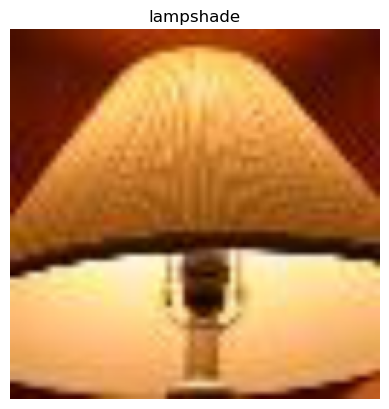

In [9]:
EMBEDDING_DIM = 768

# Eq. 1: Conv2d(kernel=stride=P) == linear projection E
conv2d = nn.Conv2d(
    in_channels=3,
    out_channels=EMBEDDING_DIM,
    kernel_size=PATCH_SIZE,
    stride=PATCH_SIZE,
    padding=0
)

plt.imshow(image_permuted)
plt.title(class_name)
plt.axis(False);

In [10]:
image_batch = image.unsqueeze(0)
image_out_of_conv = conv2d(image_batch)

print(f"image_batch shape      : {image_batch.shape}")
print(f"image_out_of_conv shape: {image_out_of_conv.shape}  -> [batch, D, H/P, W/P]")


image_batch shape      : torch.Size([1, 3, 224, 224])
image_out_of_conv shape: torch.Size([1, 768, 14, 14])  -> [batch, D, H/P, W/P]


In [11]:
single_feature_map = image_out_of_conv[:, 0, :, :]
print(f"single_feature_map     : {single_feature_map.shape}  requires_grad={single_feature_map.requires_grad}")

flatten = nn.Flatten(start_dim=2, end_dim=3)

# Eq. 1: flatten patches [B, D, H, W] -> [B, D, N]
image_out_of_conv          = conv2d(image.unsqueeze(0))
image_out_of_conv_flattened = flatten(image_out_of_conv)

# Eq. 1: permute to [B, N, D] — patch token sequence
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1)

print(f"\nShape flow:")
print(f"  image                : {image.shape}")
print(f"  after conv2d         : {image_out_of_conv.shape}")
print(f"  after flatten        : {image_out_of_conv_flattened.shape}")
print(f"  after permute [B,N,D]: {image_out_of_conv_flattened_reshaped.shape}")

single_flattened_feature_map = image_out_of_conv_flattened_reshaped[:, :, 0]

print(f"\nsingle_flattened_feature_map: {single_flattened_feature_map.shape}  requires_grad={single_flattened_feature_map.requires_grad}")

single_feature_map     : torch.Size([1, 14, 14])  requires_grad=True

Shape flow:
  image                : torch.Size([3, 224, 224])
  after conv2d         : torch.Size([1, 768, 14, 14])
  after flatten        : torch.Size([1, 768, 196])
  after permute [B,N,D]: torch.Size([1, 196, 768])

single_flattened_feature_map: torch.Size([1, 196])  requires_grad=True


In [13]:
class PatchEmbedding(nn.Module):
    def __init__(self,
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=768):
        super().__init__()

        self.patch_size = patch_size

        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        self.flatten = nn.Flatten(start_dim=2, end_dim=3)

    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0, (
            f"Input image size must be divisible by patch size, "
            f"image shape: {image_resolution}, patch size: {self.patch_size}"
        )
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        return x_flattened.permute(0, 2, 1)


In [14]:
patchify = PatchEmbedding(in_channels=3, patch_size=8, embedding_dim=768)

x_test = torch.randn(1, 3, 64, 64)
out    = patchify(x_test)
print(f"PatchEmbedding output : {out.shape}")
print(f"Expected              : [1, 64, 768]  -> [B, N, D]")

PatchEmbedding output : torch.Size([1, 64, 768])
Expected              : [1, 64, 768]  -> [B, N, D]


In [15]:
class MultiheadSelfAttentionBlock(nn.Module):
    def __init__(self,
                 embedding_dim:int=768,
                 num_heads:int=12,
                 attn_dropout:float=0):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                    num_heads=num_heads,
                                                    dropout=attn_dropout,
                                                    batch_first=True)

    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attn(query=x,
                                             key=x,
                                             value=x,
                                             need_weights=False)
        return attn_output


In [16]:
class MLPBlock(nn.Module):
    def __init__(self,
                 embedding_dim:int=768,
                 mlp_size:int=3072,
                 dropout:float=0.1):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim, out_features=mlp_size),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, out_features=embedding_dim),
            nn.Dropout(p=dropout)
        )

    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x


In [17]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self,
                 embedding_dim:int=768,
                 num_heads:int=12,
                 mlp_size:int=3072,
                 mlp_dropout:float=0.1,
                 attn_dropout:float=0):
        super().__init__()

        self.msa_block = MultiheadSelfAttentionBlock(embedding_dim=embedding_dim,
                                                     num_heads=num_heads,
                                                     attn_dropout=attn_dropout)

        self.mlp_block = MLPBlock(embedding_dim=embedding_dim,
                                  mlp_size=mlp_size,
                                  dropout=mlp_dropout)

    def forward(self, x):
        x = self.msa_block(x) + x   # Eq. 2
        x = self.mlp_block(x) + x   # Eq. 3
        return x


In [18]:
transformer_encoder_block = TransformerEncoderBlock()

dummy = torch.randn(2, 197, 768)
out   = transformer_encoder_block(dummy)
print(f"EncoderBlock input  : {dummy.shape}")
print(f"EncoderBlock output : {out.shape}")

torch_transformer_encoder_layer = nn.TransformerEncoderLayer(
    d_model=768, nhead=12, dim_feedforward=3072,
    dropout=0.1, activation="gelu", batch_first=True, norm_first=True
)
torch_out = torch_transformer_encoder_layer(dummy)
print(f"PyTorch built-in    : {torch_out.shape}")


EncoderBlock input  : torch.Size([2, 197, 768])
EncoderBlock output : torch.Size([2, 197, 768])
PyTorch built-in    : torch.Size([2, 197, 768])


In [19]:
class ViT(nn.Module):
    def __init__(self,
                 img_size:int=224,
                 in_channels:int=3,
                 patch_size:int=16,
                 num_transformer_layers:int=12,
                 embedding_dim:int=768,
                 mlp_size:int=3072,
                 num_heads:int=12,
                 attn_dropout:float=0,
                 mlp_dropout:float=0.1,
                 embedding_dropout:float=0.1,
                 num_classes:int=200):
        super().__init__()

        assert img_size % patch_size == 0, (
            f"Image size must be divisible by patch size, "
            f"image size: {img_size}, patch size: {patch_size}."
        )

        self.num_patches = (img_size * img_size) // patch_size**2

        # Eq. 1: learnable class token z_class
        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, embedding_dim),
                                            requires_grad=True)

        # Eq. 1: learnable 1D position embeddings E_pos
        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches + 1, embedding_dim),
                                               requires_grad=True)

        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        # Eq. 1: linear projection E
        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                              patch_size=patch_size,
                                              embedding_dim=embedding_dim)

        self.transformer_encoder = nn.Sequential(*[
            TransformerEncoderBlock(embedding_dim=embedding_dim,
                                    num_heads=num_heads,
                                    mlp_size=mlp_size,
                                    mlp_dropout=mlp_dropout)
            for _ in range(num_transformer_layers)
        ])

        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim, out_features=num_classes)
        )

    def forward(self, x):
        batch_size = x.shape[0]

        # Eq. 1: patch + position embedding → [B, N+1, D]
        class_token = self.class_embedding.expand(batch_size, -1, -1)
        x = self.patch_embedding(x)
        x = torch.cat((class_token, x), dim=1)
        x = self.position_embedding + x
        x = self.embedding_dropout(x)

        # Eq. 2 & 3: L encoder blocks → [B, N+1, D]
        x = self.transformer_encoder(x)

        # Eq. 4: CLS token → LN → Linear → [B, num_classes]
        return self.classifier(x[:, 0])


In [20]:
vit = ViT(img_size=64, patch_size=8, num_classes=200)

In [21]:
test_input  = torch.randn(4, 3, 64, 64)
test_output = vit(test_input)

total_params     = sum(p.numel() for p in vit.parameters())
trainable_params = sum(p.numel() for p in vit.parameters() if p.requires_grad)

print(f"Input  : {test_input.shape}")
print(f"Output : {test_output.shape}")
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

Input  : torch.Size([4, 3, 64, 64])
Output : torch.Size([4, 200])

Total params     : 85,408,712
Trainable params : 85,408,712


In [22]:
def train_one_epoch(model, loader, optimizer, loss_fn, scheduler, device):
    model.train()
    total_loss = correct = total = 0
    ctx = torch.autocast(device_type="cuda", dtype=torch.bfloat16) if device == "cuda" else nullcontext()
    for imgs, labels in tqdm(loader, leave=False, desc="  train"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with ctx:
            logits = model(imgs)
            loss   = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    if scheduler is not None:
        scheduler.step()
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = correct = total = 0
    ctx = torch.autocast(device_type="cuda", dtype=torch.bfloat16) if device == "cuda" else nullcontext()
    for imgs, labels in tqdm(loader, leave=False, desc="  val  "):
        imgs, labels = imgs.to(device), labels.to(device)
        with ctx:
            logits = model(imgs)
            loss   = loss_fn(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

def cosine_schedule_with_warmup(optimizer, warmup_epochs: int, total_epochs: int):
    def lr_lambda(epoch: int) -> float:
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [23]:
EPOCHS          = 10
WARMUP_EPOCHS   = 4
LR              = 1e-3
WEIGHT_DECAY    = 0.05
LABEL_SMOOTHING = 0.1

vit_scratch = ViT(img_size=64, patch_size=8, num_classes=200).to(device)
optimizer_scratch = torch.optim.AdamW(
    vit_scratch.parameters(),
    lr=LR, betas=(0.9, 0.999), weight_decay=WEIGHT_DECAY,
)
scheduler_scratch = cosine_schedule_with_warmup(
    optimizer_scratch, warmup_epochs=WARMUP_EPOCHS, total_epochs=EPOCHS
)
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

print(f"Model params : {sum(p.numel() for p in vit_scratch.parameters()):,}\n")
print(f"Epochs       : {EPOCHS}  (warmup: {WARMUP_EPOCHS})")
print(f"LR           : {LR}")
print(f"Weight decay : {WEIGHT_DECAY}")
print(f"Label smooth : {LABEL_SMOOTHING}")
print(f"Device       : {device}")

Model params : 85,408,712

Epochs       : 10  (warmup: 4)
LR           : 0.001
Weight decay : 0.05
Label smooth : 0.1
Device       : mps


In [24]:
scratch_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}  {'LR':>8}")

for epoch in range(1, EPOCHS + 1):
    current_lr = optimizer_scratch.param_groups[0]["lr"]
    train_loss, train_acc = train_one_epoch(
        vit_scratch, train_loader, optimizer_scratch,
        loss_fn, scheduler_scratch, device,
    )
    val_loss, val_acc = evaluate(vit_scratch, val_loader, loss_fn, device)
    scratch_history["train_loss"].append(train_loss)
    scratch_history["val_loss"].append(val_loss)
    scratch_history["train_acc"].append(train_acc)
    scratch_history["val_acc"].append(val_acc)
    print(f"{epoch:>6}  {train_loss:>10.4f}  {train_acc*100:>8.2f}%  "
          f"{val_loss:>8.4f}  {val_acc*100:>6.2f}%  {current_lr:.2e}")

print(f"Best val acc: {max(scratch_history['val_acc'])*100:.2f}%")


 Epoch  Train Loss  Train Acc  Val Loss  Val Acc        LR


  train:   0%|          | 0/3125 [00:04<?, ?it/s]

  val  :   0%|          | 0/313 [00:03<?, ?it/s]

     1      4.9401      4.20%    4.6682    7.49%  2.50e-04


  train:   0%|          | 0/3125 [00:03<?, ?it/s]

...

  val  :   0%|          | 0/313 [00:03<?, ?it/s]

     9      4.6318      8.06%    4.5840    8.81%  2.50e-04


  train:   0%|          | 0/3125 [00:04<?, ?it/s]

  val  :   0%|          | 0/313 [00:03<?, ?it/s]

    10      4.5623      9.00%    4.5343    9.47%  6.70e-05
Best val acc: 9.47%


In [25]:
pretrained_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_weights).to(device)

for param in pretrained_vit.parameters():
    param.requires_grad = False

pretrained_vit.heads = nn.Linear(in_features=768, out_features=200).to(device)

trainable = sum(p.numel() for p in pretrained_vit.parameters() if p.requires_grad)
total     = sum(p.numel() for p in pretrained_vit.parameters())
print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}  ({100*trainable/total:.1f}% of total)\n")
pretrained_transforms = pretrained_weights.transforms()
print(f"Pretrained transforms: {pretrained_transforms}")

Total params     : 85,952,456
Trainable params : 153,800  (0.2% of total)

Pretrained transforms: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [26]:
train_dataset_pt = TinyImageNet(DATA_DIR, split="train", transform=pretrained_transforms)
val_dataset_pt   = TinyImageNet(DATA_DIR, split="val",   transform=pretrained_transforms)

train_loader_pt = DataLoader(train_dataset_pt, batch_size=256, shuffle=True,
                             num_workers=_workers, pin_memory=_pin, drop_last=True)
val_loader_pt   = DataLoader(val_dataset_pt, batch_size=256, shuffle=False,
                             num_workers=_workers, pin_memory=_pin)

In [27]:
EPOCHS = 10
optimizer_pt = torch.optim.Adam(pretrained_vit.parameters(), lr=1e-3)
scheduler_pt = cosine_schedule_with_warmup(optimizer_pt, warmup_epochs=2, total_epochs=EPOCHS)
loss_fn_pt   = nn.CrossEntropyLoss()

ft_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        pretrained_vit, train_loader_pt, optimizer_pt,
        loss_fn_pt, scheduler_pt, device,
    )
    val_loss, val_acc = evaluate(pretrained_vit, val_loader_pt, loss_fn_pt, device)
    ft_history["train_loss"].append(train_loss)
    ft_history["val_loss"].append(val_loss)
    ft_history["train_acc"].append(train_acc)
    ft_history["val_acc"].append(val_acc)
    print(f"{epoch:>6}  {train_loss:>10.4f}  {train_acc*100:>8.2f}%  "
          f"{val_loss:>8.4f}  {val_acc*100:>6.2f}%")

print(f"Best val acc: {max(ft_history['val_acc'])*100:.2f}%")

 Epoch  Train Loss  Train Acc  Val Loss  Val Acc


  train:   0%|          | 0/390 [00:03<?, ?it/s]

  val  :   0%|          | 0/40 [00:03<?, ?it/s]

     1      1.4488     75.52%    0.7279   82.02%


  train:   0%|          | 0/390 [00:03<?, ?it/s]

...

  val  :   0%|          | 0/40 [00:03<?, ?it/s]

     9      0.2845     92.70%    0.6117   83.93%


  train:   0%|          | 0/390 [00:03<?, ?it/s]

  val  :   0%|          | 0/40 [00:03<?, ?it/s]

    10      0.2760     92.99%    0.6113   83.96%
Best val acc: 84.06%


In [33]:
best_scratch_acc = max(scratch_history["val_acc"]) * 100
best_ft_acc      = max(ft_history["val_acc"])      * 100

print(f"{'Strategy':<40} {'Best Val Acc':>12}")
print(f"{'ViT-B/16 trained from scratch (10 epochs)':<40} {best_scratch_acc:>11.2f}%")
print(f"{'ViT-B/16 pretrained (ImageNet-21k), fine-tuned':<40} {best_ft_acc:>11.2f}%")

Strategy                                 Best Val Acc
ViT-B/16 trained from scratch (10 epochs)        9.47%
ViT-B/16 pretrained (ImageNet-21k), fine-tuned       84.06%
